In [1]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from pprint import pprint

In [2]:
match_df = pl.read_parquet('Skillcorner data/RealMadrid/matches.parquet')
# Data is only available for "closed" matches
match_df = match_df.filter(pl.col('status') == 'closed')
match_ids = match_df['id'].to_list()
# match_ids = match_df.filter(pl.col('competition_edition_id').is_in([900, 546]))['id'].to_list()
print('Num of matches:', len(match_ids))

Num of matches: 98


In [ ]:
REAL_MADRID_TEAM_ID = 262

# Derived data storage
data = {
  'match_id': [],
  'rma_shots': [],
  'rma_goals': [],
  'def_median': [],
  'mid_median': [],
  'att_median': [],
  'def_compact': [],
  'mid_compact': [],
  'att_compact': [],
}

for match_id in match_ids:
  # Load meta data for match
  meta_df = pl.read_json(f'Skillcorner data/RealMadrid/meta/{match_id}.json')
  meta_players_df = meta_df.select('players').explode('players').unnest('players')
  meta_players_df = (
    meta_players_df.with_columns(
      pl.col('player_role').name.prefix_fields('player_role_')
    ).unnest('player_role')
  ).rename({'id': 'player_id', 'short_name': 'player_short_name'})
  rma_player_ids = meta_players_df.filter(pl.col('team_id') == REAL_MADRID_TEAM_ID)['player_id'].to_list()
  oppo_player_ids = meta_players_df.filter(pl.col('team_id') != REAL_MADRID_TEAM_ID)['player_id'].to_list()

  # Transform data so that Real Madrid is alway left to right
  # First determine which half to transform coordinates
  is_rma_home = (meta_df['home_team'].struct.field('id') == REAL_MADRID_TEAM_ID).item()
  home_l2r_half = meta_df['home_team_side'].item().to_list().index('right_to_left') + 1
  if is_rma_home:
    period_to_swap = home_l2r_half
  else:
    period_to_swap = 3 - home_l2r_half

  # Load tracking data for match
  track_df = pl.read_json(f'Skillcorner data/RealMadrid/tracking/{match_id}.json', infer_schema_length=10_000)
  # Only get rows that have valid timestamps and players
  track_frames_df = track_df.filter(pl.col('timestamp').is_not_null(), pl.col('player_data').list.len() != 0)
  ball_coords_df = track_frames_df.select(
    pl.col('frame'),
    pl.col('period'),
    pl.col('ball_data').struct.field('x'),
    pl.col('ball_data').struct.field('y'),
  )
  track_players_df = (                                                                                                               
      track_frames_df.select(['frame', 'timestamp', 'period', 'player_data'])                                                                         
      .explode('player_data')                                                                                                        
      .unnest('player_data')
  )
  # SkillCorner coordinate origin is located at the pitch center point
  # Horizontal coordinates go from -52.5 to 52.5, so to transform the
  # opposite direction we multiply by -1
  track_players_df = track_players_df.with_columns(
    pl.when(pl.col('period') == period_to_swap)
    .then(pl.col('x') * -1)
    .otherwise(pl.col('x'))
  )
  ball_coords_df = ball_coords_df.with_columns(
    pl.when(pl.col('period') == period_to_swap)
    .then(pl.col('x') * -1)
    .otherwise(pl.col('x'))
  )
  # With all coordinates transformed for left to right for Real Madrid,
  # we can filter frames when the ball is in each third of the pitch.
  # +--------------------------------+--------------------------------+
  # |                     !          |          !                     |
  # |----+                !          |          !                +----|
  # |    |                !          |          !                |    |
  # |  RMA defensive 3rd  !     RMA mid 3rd     !  RMA attacking 3rd  |
  # |   -52.5 to -17.5    !    -17.5 to 17.5    !    17.5 to 52.5     |
  # |         35m         !         35m         !         35m         |
  # |    |                !          |          !                |    |
  # |----+                !          |          !                +----|
  # |                     !          |          !                     |
  # +--------------------------------+--------------------------------+
  def_third_frames = ball_coords_df.filter(pl.col('x') < -17.5)['frame'].to_list()
  mid_third_frames = ball_coords_df.filter(pl.col('x').is_between(-17.5, 17.5))['frame'].to_list()
  att_third_frames = ball_coords_df.filter(pl.col('x') > 17.5)['frame'].to_list()

  # Load dynamic events for match
  try:
    dynam_df = pl.read_parquet(f'Skillcorner data/RealMadrid/dynamic/{match_id}.parquet')
  except FileNotFoundError:
    print(f'Missing dynamic data for match id {match_id}!')
    continue
  num_rma_shots = dynam_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('end_type') == 'shot',
  ).shape[0]
  num_rma_goals = dynam_df.filter(
    pl.col('team_id') == REAL_MADRID_TEAM_ID,
    pl.col('game_interruption_after') == 'goal_for'
  ).shape[0]

  # Tracking data for each team
  rma_track_df = track_players_df.filter(pl.col('player_id').is_in(rma_player_ids))
  oppo_track_df = track_players_df.filter(pl.col('player_id').is_in(oppo_player_ids))

  # To get all the opponent's defensive frames we filter when the ball is in RMA's attacking 3rd
  oppo_def_frames_df = oppo_track_df.filter(pl.col('frame').is_in(att_third_frames))
  oppo_mid_frames_df = oppo_track_df.filter(pl.col('frame').is_in(mid_third_frames))
  # Likewise, for the opponent's attacking frames we filter when the ball is in RMA's defensive 3rd
  oppo_att_frames_df = oppo_track_df.filter(pl.col('frame').is_in(def_third_frames))

  # Here we get the median value of the opponent defender closest to the opponent's goal (highest x value) over the match
  def_median = oppo_def_frames_df.group_by('frame').agg(pl.col('x').max())['x'].median()
  mid_median = oppo_mid_frames_df.group_by('frame').agg(pl.col('x').max())['x'].median()
  # This gets the median of the highest meter the opponent's defense gets when attacking RMA
  att_median = oppo_att_frames_df.group_by('frame').agg(pl.col('x').max())['x'].median()

  # Calculate the average compactness of the defense by getting the mean squared distance
  # from the centroid of all players
  avg_def_compactness = oppo_def_frames_df.with_columns(
    pl.col('x').mean().over('frame').alias('centroid_x'),
    pl.col('y').mean().over('frame').alias('centroid_y'),
  ).with_columns(
    ((pl.col('x') - pl.col('centroid_x')) ** 2 +
     (pl.col('y') - pl.col('centroid_y') ** 2)).alias('sq_dist')
  ).group_by('frame').agg(
    pl.col('sq_dist').mean().alias('compactness')
  )['compactness'].mean()

  # Populate data
  data['match_id'].append(match_id)
  data['rma_shots'].append(num_rma_shots)
  data['rma_goals'].append(num_rma_goals)
  data['def_median'].append(def_median)
  data['mid_median'].append(mid_median)
  data['att_median'].append(att_median)
  data['def_compact'].append(avg_def_compactness)

print('Num data points:', len(data['match_id']))


Missing dynamic data for match id 1274919!
Num data points: 97


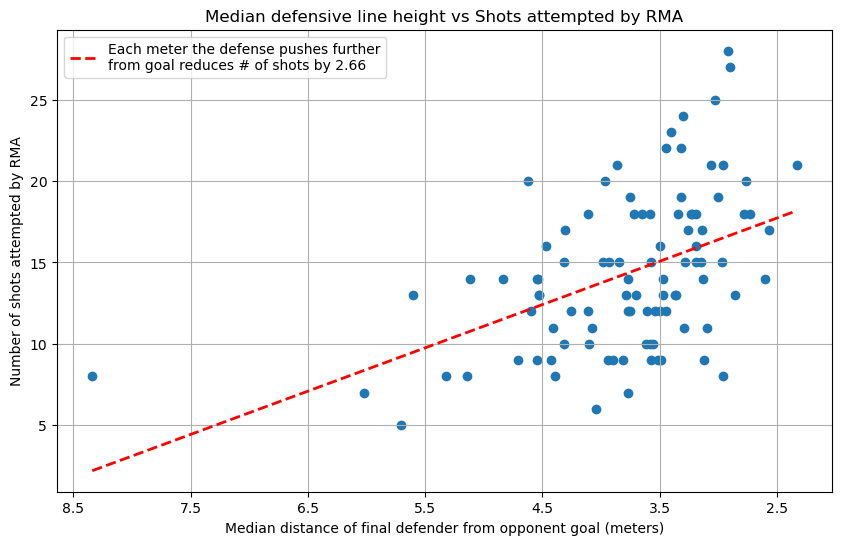

In [6]:
plt.figure(figsize=(10,6))
x = data['def_median']
y = data['rma_shots']
plt.scatter(x, y)

# Label points with match ids
# ids = data['match_id']
# for xi, yi, mid in zip(x, y, ids):
#   plt.annotate(str(mid), (xi, yi), textcoords="offset points", xytext=(5,5), ha='left', fontsize=9)

# Regression line
x_arr = np.array(x)
y_arr = np.array(y)
coeffs = np.polyfit(x_arr, y_arr, 1)
slope, intercept = coeffs
x_line = np.linspace(x_arr.min(), x_arr.max(), 200)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, label=f'Each meter the defense pushes further\nfrom goal reduces # of shots by {slope:.2f}')
plt.title('Median defensive line height vs Shots attempted by RMA')

# Relabel x ticks in terms of distance from goal
x_positions, x_labels = plt.xticks()
x_lim = plt.xlim()
new_labels = []
for x in x_labels:
  new_labels.append(52.5 - x.get_position()[0])
plt.xticks(x_positions, new_labels)
plt.xlim(x_lim)
plt.xlabel('Median distance of final defender from opponent goal (meters)')

plt.ylabel('Number of shots attempted by RMA')
plt.legend()
plt.grid(True)
plt.show()

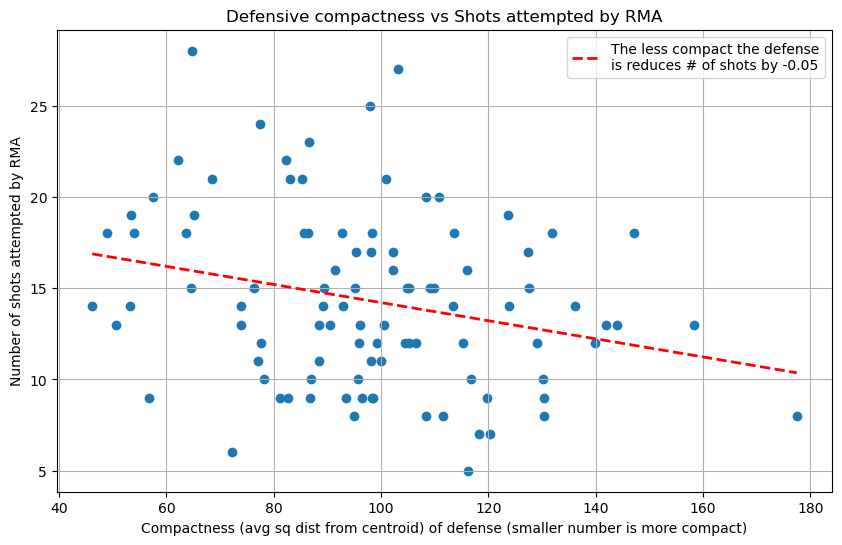

In [7]:
plt.figure(figsize=(10,6))
x = data['def_compact']
y = data['rma_shots']
plt.scatter(x, y)

# Label points with match ids
# ids = data['match_id']
# for xi, yi, mid in zip(x, y, ids):
#   plt.annotate(str(mid), (xi, yi), textcoords="offset points", xytext=(5,5), ha='left', fontsize=9)

# Regression line
x_arr = np.array(x)
y_arr = np.array(y)
coeffs = np.polyfit(x_arr, y_arr, 1)
slope, intercept = coeffs
x_line = np.linspace(x_arr.min(), x_arr.max(), 200)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, label=f'The less compact the defense\nis reduces # of shots by {slope:.2f}')

plt.title('Defensive compactness vs Shots attempted by RMA')
plt.xlabel('Compactness (avg sq dist from centroid) of defense (smaller number is more compact)')
plt.ylabel('Number of shots attempted by RMA')
plt.legend()
plt.grid(True)
plt.show()

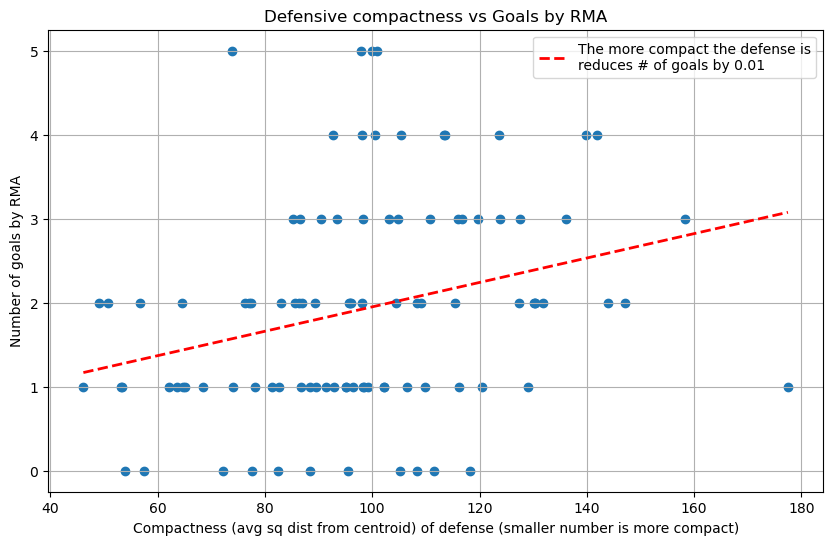

In [8]:
plt.figure(figsize=(10,6))
x = data['def_compact']
y = data['rma_goals']
plt.scatter(x, y)

# Label points with match ids
# ids = data['match_id']
# for xi, yi, mid in zip(x, y, ids):
#   plt.annotate(str(mid), (xi, yi), textcoords="offset points", xytext=(5,5), ha='left', fontsize=9)

# Regression line
x_arr = np.array(x)
y_arr = np.array(y)
coeffs = np.polyfit(x_arr, y_arr, 1)
slope, intercept = coeffs
x_line = np.linspace(x_arr.min(), x_arr.max(), 200)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, label=f'The more compact the defense is\nreduces # of goals by {slope:.2f}')

plt.title('Defensive compactness vs Goals by RMA')
plt.xlabel('Compactness (avg sq dist from centroid) of defense (smaller number is more compact)')
plt.ylabel('Number of goals by RMA')
plt.legend()
plt.grid(True)
plt.show()